# *Olist E-Commerce: Delivery Performance & Seller Segmentation*

**Objective:** Understand what drives late deliveries in the Olist marketplace, quantify how much
delay affects customer satisfaction, and segment sellers by performance so the business can
identify who to invest in, retain, or flag for improvement.

**Dataset:** Olist Brazilian E-Commerce public dataset (customers, orders, order items, payments,
products, reviews, sellers, geolocation).

**Structure of this notebook:**
1. Setup & Data Loading
2. Data Cleaning
3. Database Setup
4. Delivery Performance Overview
5. Payment Behavior
6. Seller Performance Snapshot
7. Drivers of Delivery Delay
8. Seller Segmentation (Clustering)
9. Conclusion & Recommendations


## 1. Setup & Data Loading

In [3]:
import pandas as pd
import sqlite3 as sq
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr


In [7]:
DATA_DIR = r"C:\Users\anand\Desktop\Olist"

customers   = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
orders      = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv")
order_items = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
payments    = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
products    = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
reviews     = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv")
sellers     = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
geolocation = pd.read_csv(f"{DATA_DIR}/olist_geolocation_dataset.csv")


## 2. Data Cleaning & Reformatting

In [8]:
orders.rename(columns={
    "order_purchase_timestamp": "purchased_at",
    "order_delivered_carrier_date": "delivered_carrier_date",
    "order_delivered_customer_date": "delivered_customer_date",
    "order_estimated_delivery_date": "estimated_delivery_date"
}, inplace=True)

for col in ["purchased_at", "order_approved_at", "delivered_carrier_date",
            "delivered_customer_date", "estimated_delivery_date"]:
    orders[col] = pd.to_datetime(orders[col])


In [9]:
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])


In [10]:
payments["payment_type"] = payments["payment_type"].replace({"not_defined": "cod"})


In [11]:
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])


## 3. Database Setup

Loading the cleaned tables into an in-memory-style SQLite database so the rest of the
analysis can be written as SQL, which is easier to audit and reuse than chained pandas.

In [12]:
conn = sq.connect("olist.db")
cursor = conn.cursor()

customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
sellers.to_sql("sellers", conn, if_exists="replace", index=False)
geolocation.to_sql("geolocation", conn, if_exists="replace", index=False)


1000163

## 4. Delivery Performance Overview

### 4.1 Delay Percentage — Overall

In [13]:
pd.read_sql("""
SELECT ROUND(AVG(
    CASE WHEN julianday(delivered_customer_date) - julianday(purchased_at)
              > julianday(estimated_delivery_date) - julianday(purchased_at)
         THEN 1 ELSE 0 END
) * 100.0, 0) AS delayed_percentage
FROM orders
WHERE order_status NOT IN ('canceled', 'unavailable');
""", conn)


,delayed_percentage
0,8.0


### 4.2 Delay Contribution by Product Category

In [14]:
query = """
WITH t AS (
    SELECT SUM(CASE WHEN julianday(estimated_delivery_date) - julianday(purchased_at)
                          < julianday(delivered_customer_date) - julianday(purchased_at)
                     THEN 1 ELSE 0 END) AS delayed_delivery_count
    FROM orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
)
SELECT c.product_category_name,
       ROUND(COUNT(DISTINCT CASE
           WHEN julianday(estimated_delivery_date) - julianday(purchased_at)
                < julianday(delivered_customer_date) - julianday(purchased_at)
           THEN a.order_id END) * 100.0 / (SELECT delayed_delivery_count FROM t), 0)
           AS percentage_contribution_in_delayed_orders
FROM orders AS a
JOIN order_items AS b ON a.order_id = b.order_id
JOIN products AS c ON c.product_id = b.product_id
WHERE a.order_status NOT IN ('canceled', 'unavailable')
GROUP BY product_category_name
ORDER BY 2 DESC
LIMIT 10
"""
pd.read_sql(query, conn)


,product_category_name,percentage_contribution_in_delayed_orders
0,cama_mesa_banho,10.0
1,beleza_saude,10.0
2,moveis_decoracao,7.0
3,esporte_lazer,7.0
4,relogios_presentes,6.0
5,informatica_acessorios,6.0
6,utilidades_domesticas,5.0
7,telefonia,4.0
8,ferramentas_jardim,4.0
9,brinquedos,4.0


### 4.3 Order Volume by Weekday x Hour (Heatmap)

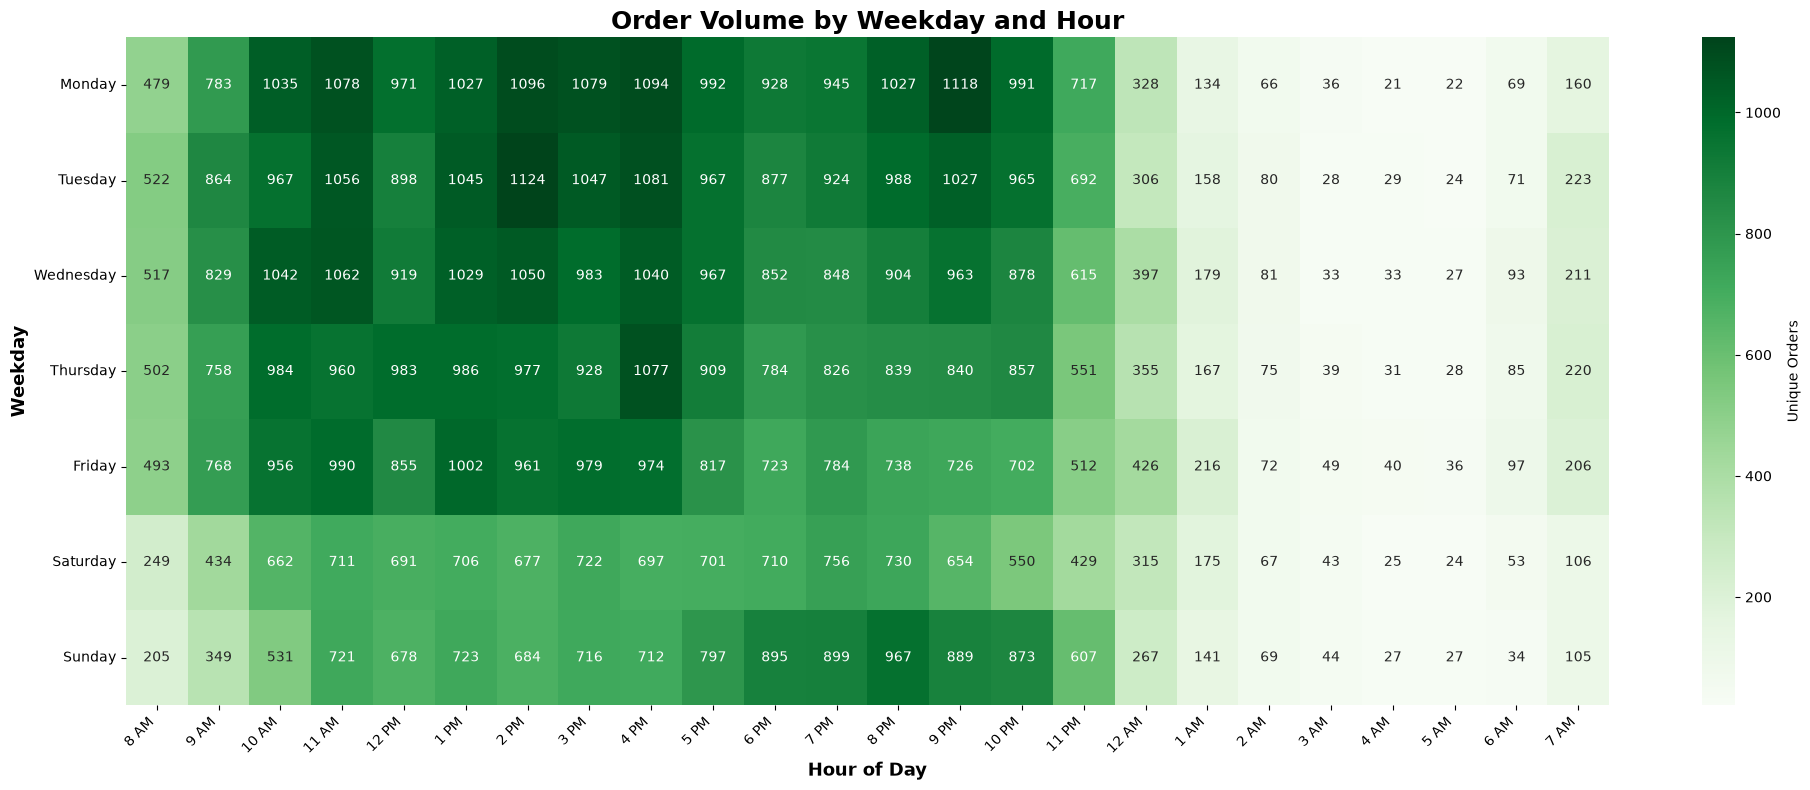

In [15]:
data = pd.DataFrame({
    "weekday": orders["purchased_at"].dt.day_name(),
    "Time": orders["purchased_at"].dt.hour,
    "order_id": orders["order_id"]
})

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hour_order = [
    "8 AM", "9 AM", "10 AM", "11 AM", "12 PM", "1 PM", "2 PM", "3 PM",
    "4 PM", "5 PM", "6 PM", "7 PM", "8 PM", "9 PM", "10 PM", "11 PM",
    "12 AM", "1 AM", "2 AM", "3 AM", "4 AM", "5 AM", "6 AM", "7 AM"
]

heatmap = data.pivot_table(index="weekday", columns="Time", values="order_id",
                            aggfunc="nunique", fill_value=0)
heatmap = heatmap.reindex(weekday_order)

column_order = []
for h in heatmap.columns:
    hour = h % 12
    if hour == 0:
        hour = 12
    column_order.append(f"{hour} AM" if h < 12 else f"{hour} PM")

heatmap.columns = column_order
heatmap = heatmap.reindex(columns=hour_order)

plt.figure(figsize=(20, 8))
sns.heatmap(heatmap, cmap="Greens", annot=True, fmt="d", linewidths=0,
            linecolor="white", cbar_kws={"label": "Unique Orders"})
plt.title("Order Volume by Weekday and Hour", fontsize=18, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=13, fontweight="bold")
plt.ylabel("Weekday", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.4 Operational Time Between Purchase and Delivery

In [16]:
query = """
WITH T AS (
    SELECT ((JULIANDAY(order_approved_at) - JULIANDAY(purchased_at)) * 24) AS a,
           ((JULIANDAY(delivered_carrier_date) - JULIANDAY(order_approved_at)) * 24) AS b,
           ((JULIANDAY(delivered_customer_date) - JULIANDAY(delivered_carrier_date)) * 24) AS c,
           ((JULIANDAY(delivered_customer_date) - JULIANDAY(purchased_at)) * 24) AS t
    FROM orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
      AND purchased_at IS NOT NULL AND order_approved_at IS NOT NULL
      AND delivered_carrier_date IS NOT NULL AND delivered_customer_date IS NOT NULL
)
SELECT ROUND((SUM(a) / SUM(t)) * 100) AS TIME_PER_BW_PURCHASE_AND_CONFRMTN,
       ROUND((SUM(b) / SUM(t)) * 100) AS TIME_PER_BW_CONFRMTN_AND_DISPATCH,
       ROUND((SUM(c) / SUM(t)) * 100) AS TIME_PER_BW_DISPATCH_DELIVERY
FROM T
"""
pd.read_sql(query, conn)


,TIME_PER_BW_PURCHASE_AND_CONFRMTN,TIME_PER_BW_CONFRMTN_AND_DISPATCH,TIME_PER_BW_DISPATCH_DELIVERY
0,3.0,22.0,74.0


In [17]:
query = """
WITH T AS (
    SELECT CAST(((julianday(order_approved_at) - julianday(purchased_at)) * 24) + 0.9999 AS INTEGER)
               AS TIME_bw_PURCHASE_AND_APPROVAL,
           CAST((julianday(delivered_carrier_date) - julianday(order_approved_at)) + 0.9999 AS INTEGER)
               AS TIME_bw_APPROVAL_AND_DISPATCH,
           CAST((julianday(delivered_customer_date) - julianday(delivered_carrier_date)) + 0.9999 AS INTEGER)
               AS TIME_bw_DISPATCH_AND_DELIVERY
    FROM orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
      AND purchased_at IS NOT NULL AND order_approved_at IS NOT NULL
      AND delivered_carrier_date IS NOT NULL AND delivered_customer_date IS NOT NULL
)
SELECT ROUND(AVG(TIME_bw_PURCHASE_AND_APPROVAL)) AS AVG_APPROVAL_IN_HOURS,
       ROUND(AVG(TIME_bw_APPROVAL_AND_DISPATCH)) AS AVG_DISPATCH_DAYS_BY_SELLER,
       ROUND(AVG(TIME_bw_DISPATCH_AND_DELIVERY)) AS AVG_TIME_BW_DISPATCH_DELIVERY_IN_DAYS
FROM T
"""
data = pd.read_sql(query, conn)
data


,AVG_APPROVAL_IN_HOURS,AVG_DISPATCH_DAYS_BY_SELLER,AVG_TIME_BW_DISPATCH_DELIVERY_IN_DAYS
0,11.0,3.0,10.0


## 5. Payment Behavior — EMI vs. No EMI Spending

In [18]:
query = """
WITH t AS (
    SELECT order_id, SUM(payment_value) AS order_value, MAX(payment_installments) AS installments
    FROM payments
    GROUP BY order_id
)
SELECT ROUND(AVG(order_value)) AS avg_order_val_with_financing_EMI
FROM t
WHERE installments > 1
"""
pd.read_sql(query, conn)


,avg_order_val_with_financing_EMI
0,199.0


In [19]:
query = """
WITH t AS (
    SELECT order_id, SUM(payment_value) AS order_value, MAX(payment_installments) AS installments
    FROM payments
    GROUP BY order_id
    HAVING COUNT(*) = 1
)
SELECT ROUND(AVG(order_value)) AS avg_order_val_without_financing_EMI
FROM t
WHERE installments < 2
"""
pd.read_sql(query, conn)


,avg_order_val_without_financing_EMI
0,121.0


**Insight:** Orders paid via EMI/installments average ~65% more in order value than single-payment orders.

## 6. Seller Performance Snapshot

### 6.1 Seller Revenue and Average Rating

In [20]:
query = """
WITH T AS (
    SELECT oi.seller_id, MAX(r.review_score) AS rating, SUM(oi.price) AS price
    FROM order_items AS oi
    JOIN reviews AS r ON oi.order_id = r.order_id
    GROUP BY oi.seller_id, oi.order_id
)
SELECT seller_id,
       SUM(price) AS SELLER_REVENUE,
       ROUND(AVG(rating), 1) AS SELLER_RATING_AVG,
       ROUND((SUM(price) * 1.0 / (SELECT SUM(price) FROM order_items) * 100), 2)
           AS PERCENTAGE_SHARE_OF_TOTAL_REVENUE
FROM T
GROUP BY seller_id
ORDER BY 2 DESC, 3 DESC, 4 DESC
LIMIT 10
"""
pd.read_sql(query, conn)


,seller_id,SELLER_REVENUE,SELLER_RATING_AVG,PERCENTAGE_SHARE_OF_TOTAL_REVENUE
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,4.1,1.69
1,53243585a1d6dc2643021fd1853d8905,222776.05,4.1,1.64
2,4a3ca9315b744ce9f8e9374361493884,202999.12,3.8,1.49
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,4.3,1.43
4,7c67e1448b00f6e969d365cea6b010ab,189417.67,3.5,1.39
5,7e93a43ef30c4f03f38b393420bc753a,176431.87,4.2,1.30
6,da8622b14eb17ae2831f4ac5b9dab84a,162723.37,4.2,1.20
7,7a67c85e85bb2ce8582c35f2203ad736,142325.49,4.2,1.05
8,1025f0e2d44d7041d6cf58b6550e0bfa,140513.14,4.0,1.03
9,955fee9216a65b617aa5c0531780ce60,135241.70,4.1,1.00


### 6.2 Seller Ranking — Composite KPI

Weighted score: 30% Revenue, 30% Customer Satisfaction, 25% Delivery Performance, 15% Order Volume — indexed against the highest-performing seller.

In [21]:
query = """
WITH t1 AS (
    SELECT oi.seller_id, o.order_id, SUM(oi.price) AS price, MAX(r.review_score) AS rating,
           o.delivered_customer_date AS delivered, o.estimated_delivery_date AS estimated
    FROM orders AS o
    JOIN order_items AS oi ON o.order_id = oi.order_id
    JOIN reviews AS r ON o.order_id = r.order_id
    GROUP BY oi.seller_id, o.order_id
),
t2 AS (
    SELECT seller_id, order_id, price, rating,
           CASE WHEN delivered <= estimated THEN 1 ELSE 0 END AS ontime
    FROM t1
),
t3 AS (
    SELECT seller_id, SUM(price) AS price FROM t2 GROUP BY 1
),
t4 AS (
    SELECT seller_id, COUNT(*) AS order_delivered FROM t2 GROUP BY 1
)
SELECT seller_id,
       ROUND((
           SUM(price) * 1.0 / (SELECT MAX(price) FROM t3) * 0.3
           + (SUM(ontime) * 1.0 / COUNT(*)) * 0.3
           + AVG(rating) / 5 * 0.25
           + COUNT(*) * 1.0 / (SELECT MAX(order_delivered) FROM t4) * 0.15
       ) * 100) AS seller_score
FROM t2
GROUP BY seller_id
ORDER BY 2 DESC
"""
pd.read_sql(query, conn)


,seller_id,seller_score
0,4a3ca9315b744ce9f8e9374361493884,86.0
1,4869f7a5dfa277a7dca6462dcf3b52b2,86.0
2,53243585a1d6dc2643021fd1853d8905,81.0
3,da8622b14eb17ae2831f4ac5b9dab84a,80.0
4,fa1c13f2614d7b5c4749cbc52fecda94,78.0
...,...,...
3090,15aec03fe4cf30dfa574cf550f5ff5ff,5.0
3091,15ac3c501e2599e4917316fde5c5669a,5.0
3092,154bdf805377afea75a3bd158e9eab10,5.0
3093,0aa124728afc1131dff5655f4c6f487b,5.0


## 7. Drivers of Delivery Delay

Each sub-section below tests one candidate driver of delivery delay using Spearman's
rank correlation (robust to non-linearity/outliers, appropriate since delay is not
normally distributed).

In [23]:
def spearman_delay_analysis(query, x_col, y_col, title, xlabel, ylabel, conn):
    data = pd.read_sql(query, conn)
    corr, p_value = spearmanr(data[x_col], data[y_col])
    print(f"Spearman correlation: {corr:.4f}")
    print(f"P value: {p_value:.4g}")

    plt.figure(figsize=(10, 5))
    plt.scatter(data[x_col], data[y_col], alpha=1, s=1, color="Indigo")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

    return data, corr, p_value


### 7.1 Delivery Delay vs. Customer Satisfaction

Spearman correlation: -0.1783
P value: 0


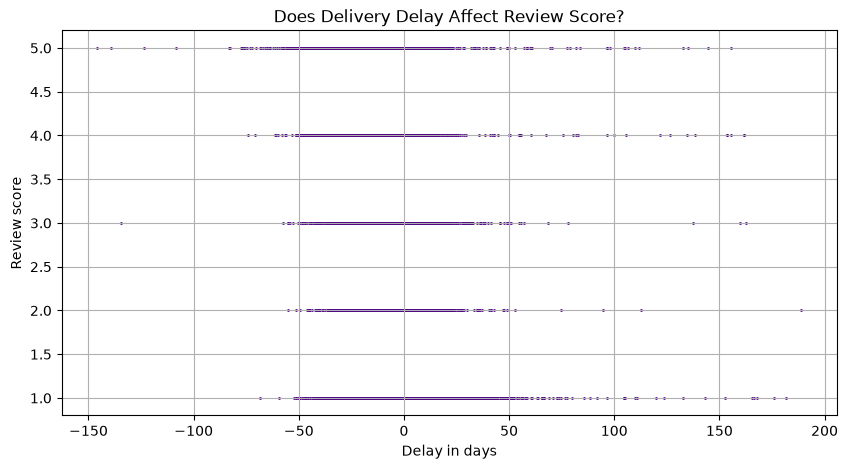

In [24]:
query = """
SELECT o.order_id, r.review_score,
       julianday(o.delivered_customer_date) - julianday(o.estimated_delivery_date) AS delay
FROM orders AS o
JOIN reviews AS r ON o.order_id = r.order_id
WHERE o.order_status NOT IN ('canceled', 'unavailable') AND o.delivered_customer_date IS NOT NULL
"""
_ = spearman_delay_analysis(
    query, x_col="delay", y_col="review_score",
    title="Does Delivery Delay Affect Review Score?",
    xlabel="Delay in days", ylabel="Review score", conn=conn
)


**Insight:** A statistically significant but weak negative correlation (ρ = -0.178, p < 0.001) — customers rate slightly lower as delay increases, but delay is only one of several factors driving satisfaction.

### 7.2 Package Volume vs. Delivery Delay

Spearman correlation: -0.0203
P value: 2.696e-10


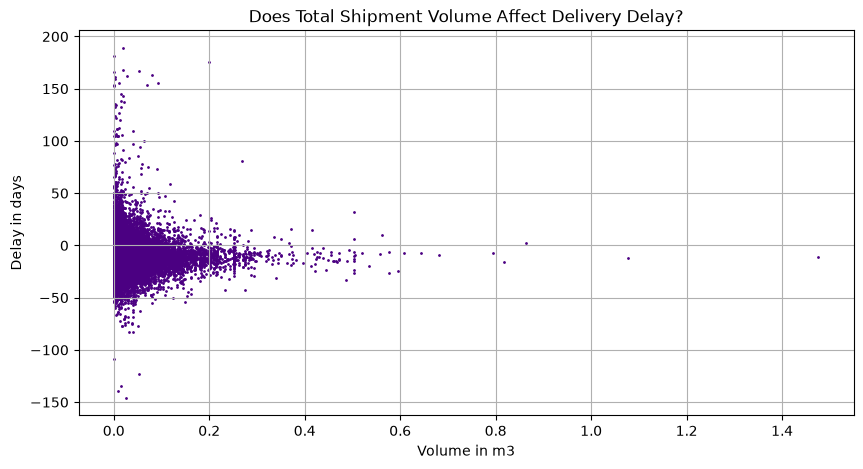

In [43]:
query = """
WITH t AS (
    SELECT SUM(p.product_length_cm * p.product_height_cm * p.product_width_cm) / 1000000.0 AS volume,
           (julianday(o.delivered_customer_date) - julianday(estimated_delivery_date)) AS delay
    FROM order_items AS oi
    JOIN products AS p ON oi.product_id = p.product_id
    JOIN orders AS o ON o.order_id = oi.order_id
    WHERE o.order_status NOT IN ('canceled', 'unavailable')
      AND delivered_customer_date IS NOT NULL AND estimated_delivery_date IS NOT NULL
    GROUP BY oi.order_id
)
SELECT * FROM t WHERE volume IS NOT NULL AND delay IS NOT NULL
"""
_ = spearman_delay_analysis(
    query, x_col="volume", y_col="delay",
    title="Does Total Shipment Volume Affect Delivery Delay?",
    xlabel="Volume in m3", ylabel="Delay in days", conn=conn
)


**Insight:** A statistically significant but negligible negative correlation (ρ = -0.0203, p < 0.001) — shipment volume has little practical effect on delay; operational/logistics factors matter far more.

### 7.3 Seller Processing Time vs. Delivery Delay

Spearman correlation: 0.1727
P value: 0


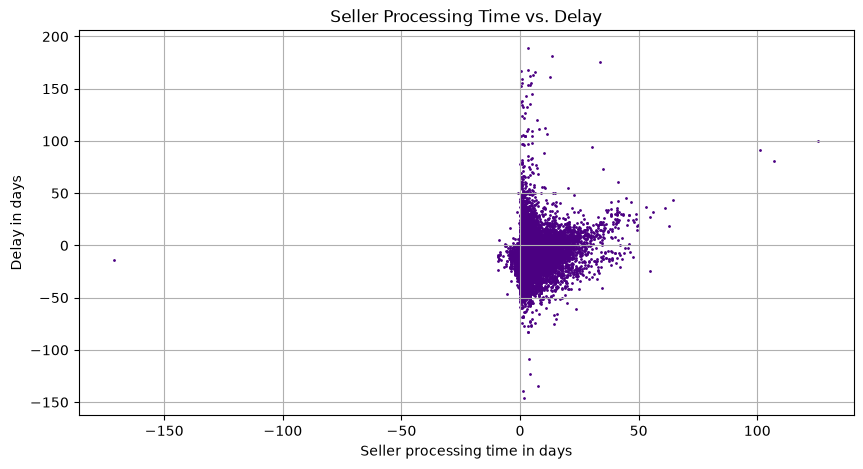

In [26]:
query = """
SELECT ((JULIANDAY(delivered_carrier_date) - JULIANDAY(order_approved_at))) AS seller_processing_time,
       ((JULIANDAY(delivered_customer_date) - JULIANDAY(estimated_delivery_date))) AS delay
FROM orders
WHERE order_status NOT IN ('canceled', 'unavailable')
  AND purchased_at IS NOT NULL AND order_approved_at IS NOT NULL
  AND delivered_carrier_date IS NOT NULL AND delivered_customer_date IS NOT NULL
  AND order_id IS NOT NULL
"""
_ = spearman_delay_analysis(
    query, x_col="seller_processing_time", y_col="delay",
    title="Seller Processing Time vs. Delay",
    xlabel="Seller processing time in days", ylabel="Delay in days", conn=conn
)


**Insight:** Statistically significant but weak positive association (ρ = 0.173, p < 0.001) — slower seller dispatch contributes to late deliveries, but is only one of several factors.

### 7.4 Carrier Transit Time vs. Delivery Delay

Spearman correlation: 0.2346
P value: 0


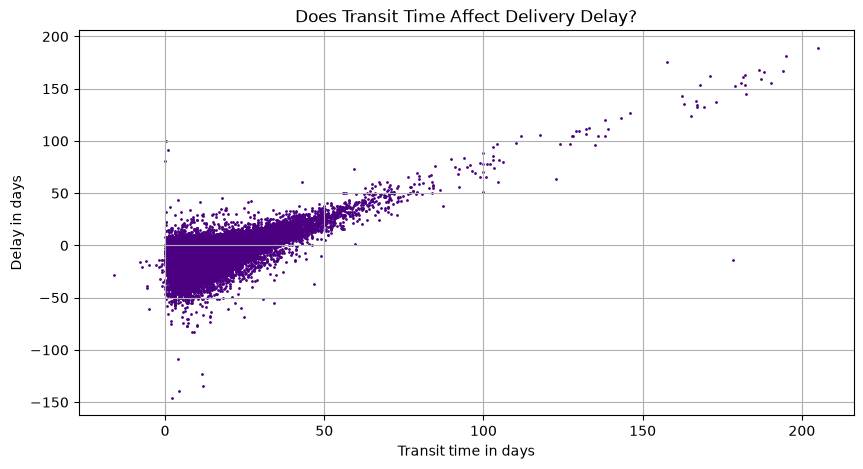

In [27]:
query = """
SELECT ((JULIANDAY(delivered_customer_date) - JULIANDAY(delivered_carrier_date))) AS transit_time,
       ((JULIANDAY(delivered_customer_date) - JULIANDAY(estimated_delivery_date))) AS delay
FROM orders
WHERE order_status NOT IN ('canceled', 'unavailable')
  AND purchased_at IS NOT NULL AND order_approved_at IS NOT NULL
  AND delivered_carrier_date IS NOT NULL AND delivered_customer_date IS NOT NULL
  AND order_id IS NOT NULL
"""
_ = spearman_delay_analysis(
    query, x_col="transit_time", y_col="delay",
    title="Does Transit Time Affect Delivery Delay?",
    xlabel="Transit time in days", ylabel="Delay in days", conn=conn
)


**Insight:** Statistically significant weak positive correlation (ρ = 0.235, p < 0.001) — the strongest of the four drivers tested. Orders spending longer in transit tend to run later overall.

### 7.5 Seller-Customer Distance vs. Delivery Delay

First, average geolocation coordinates per zip code (multiple lat/lng entries exist per zip in the raw data), then compute the great-circle distance between each seller and customer using the Haversine formula.

In [28]:
query = """
SELECT geolocation_zip_code_prefix, AVG(geolocation_lat) AS lat, AVG(geolocation_lng) AS lng
FROM geolocation
GROUP BY 1
"""
geo_avg = pd.read_sql(query, conn)
geo_avg.to_sql("geo_avg", conn, if_exists="replace", index=False)


19015

Spearman correlation: 0.18121864266950327
P value: 0.0


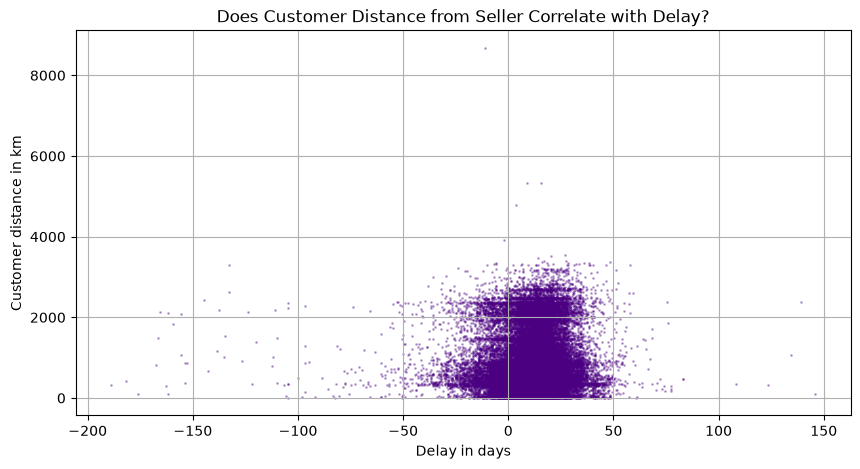

count    96000.000000
mean       602.108145
std        593.916047
min          0.000000
25%        189.317367
50%        435.633100
75%        800.275152
max       8677.911622
Name: customer_dis, dtype: float64

In [29]:
query = """
SELECT o.order_id, g1.lat AS slat, g1.lng AS slng, g2.lat AS clat, g2.lng AS clng,
       (julianday(o.estimated_delivery_date) - julianday(o.delivered_customer_date)) AS delay
FROM customers AS c
JOIN orders AS o ON c.customer_id = o.customer_id
JOIN order_items AS oi ON o.order_id = oi.order_id
JOIN sellers AS s ON s.seller_id = oi.seller_id
JOIN geo_avg AS g1 ON g1.geolocation_zip_code_prefix = s.seller_zip_code_prefix
JOIN geo_avg AS g2 ON g2.geolocation_zip_code_prefix = c.customer_zip_code_prefix
WHERE o.estimated_delivery_date IS NOT NULL AND o.delivered_customer_date IS NOT NULL
  AND o.order_id IS NOT NULL
  AND g1.lat IS NOT NULL AND g1.lng IS NOT NULL
  AND g2.lat IS NOT NULL AND g2.lng IS NOT NULL
"""
df = pd.read_sql(query, conn)

R = 6371
lat1, lat2 = np.radians(df["slat"]), np.radians(df["clat"])
lon1, lon2 = np.radians(df["slng"]), np.radians(df["clng"])
dlat, dlon = lat2 - lat1, lon2 - lon1

a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
df["distance_km"] = 2 * R * np.arcsin(np.sqrt(a))

df = (
    df.groupby("order_id", as_index=False)
      .agg(customer_dis=("distance_km", "max"), delay=("delay", "max"))
)

corr, p_value = spearmanr(df["delay"], df["customer_dis"])
print("Spearman correlation:", corr)
print("P value:", p_value)

plt.figure(figsize=(10, 5))
plt.title("Does Customer Distance from Seller Correlate with Delay?")
plt.xlabel("Delay in days")
plt.ylabel("Customer distance in km")
plt.grid(True)
plt.scatter(df["delay"], df["customer_dis"], alpha=0.3, s=1, color="Indigo")
plt.show()

df["customer_dis"].describe()


**Insight:** Statistically significant weak positive relationship (Spearman ρ ≈ 0.18) — longer shipping distance is associated with slightly higher delay, but distance alone is not a strong predictor.

### 7.6 Section Conclusion

Of the four candidate drivers tested, **carrier transit time (ρ = 0.235)** is the strongest
contributor to delivery delay, followed by seller-customer distance (ρ ≈ 0.18) and seller
processing time (ρ = 0.173). Package volume has negligible effect. **Recommendation:** prioritize
carrier/logistics optimization and improve seller-side inventory management to reduce dispatch
time, rather than focusing on package-size restrictions.

## 8. Seller Segmentation (K-Means Clustering)

Having identified *what* drives delay, we now segment sellers on revenue, rating,
delivery reliability, and volume — so the business knows *who* to invest in, retain,
or flag for improvement.

### 8.1 Build Seller Feature Table

In [30]:
query = """
WITH t1 AS (
    SELECT oi.seller_id, o.order_id, SUM(oi.price) AS price, MAX(r.review_score) AS rating,
           o.delivered_customer_date AS delivered, o.estimated_delivery_date AS estimated
    FROM orders AS o
    JOIN order_items AS oi ON o.order_id = oi.order_id
    JOIN reviews AS r ON o.order_id = r.order_id
    GROUP BY oi.seller_id, o.order_id, o.delivered_customer_date, o.estimated_delivery_date
),
t2 AS (
    SELECT seller_id, order_id, price, rating,
           CASE WHEN delivered <= estimated THEN 1 ELSE 0 END AS ontime
    FROM t1
)
SELECT seller_id,
       SUM(price) AS revenue,
       ROUND(AVG(rating), 2) AS avg_rating,
       ROUND(SUM(ontime) * 1.0 / COUNT(*), 4) AS delivery_rate,
       COUNT(*) AS order_volume
FROM t2
GROUP BY seller_id
ORDER BY revenue DESC;
"""
data = pd.read_sql(query, conn)
data.describe()


,revenue,avg_rating,delivery_rate,order_volume
count,3095.000000,3095.000000,3095.000000,3095.000000
mean,4411.368352,3.985441,0.852730,32.313409
std,13987.043983,0.962510,0.252829,105.139763
min,3.500000,1.000000,0.000000,1.000000
25%,209.550000,3.750000,0.837700,2.000000
50%,821.480000,4.170000,0.950000,6.000000
75%,3299.760000,4.600000,1.000000,21.500000
max,229472.630000,5.000000,1.000000,1854.000000


### 8.2 Feature Engineering

Revenue and order volume are heavily right-skewed (a handful of sellers dominate), so we log-transform them before scaling to prevent those sellers from dominating the distance metric K-Means relies on.

In [31]:
data["log_revenue"] = np.log1p(data["revenue"])
data["log_order_volume"] = np.log1p(data["order_volume"])
data.describe()


,revenue,avg_rating,delivery_rate,order_volume,log_revenue,log_order_volume
count,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000,3095.000000
mean,4411.368352,3.985441,0.852730,32.313409,6.751831,2.265494
std,13987.043983,0.962510,0.252829,105.139763,1.842947,1.373052
min,3.500000,1.000000,0.000000,1.000000,1.504077,0.693147
25%,209.550000,3.750000,0.837700,2.000000,5.349723,1.098612
50%,821.480000,4.170000,0.950000,6.000000,6.712324,1.945910
75%,3299.760000,4.600000,1.000000,21.500000,8.101901,3.113268
max,229472.630000,5.000000,1.000000,1854.000000,12.343543,7.525640


### 8.3 Scale Features

In [32]:
from sklearn.preprocessing import StandardScaler

features = data[["log_revenue", "avg_rating", "delivery_rate", "log_order_volume"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
X_scaled.mean(axis=0)


array([-7.34648386e-17, -3.53549536e-16,  3.76507298e-16,  1.46929677e-16])

### 8.4 Choose K — Elbow Method

In [34]:
from sklearn.cluster import KMeans

wcss = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


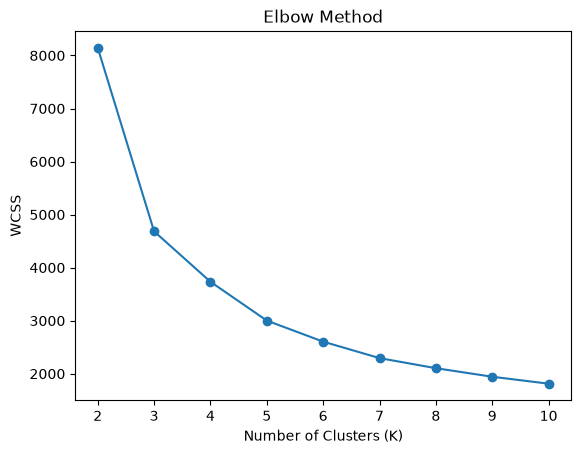

In [35]:
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


### 8.5 Choose K — Silhouette Score

The elbow plot suggests a bend around k=3–5; silhouette score is used to pick between those candidates. k=3 was selected as the winner (highest score) — print the values below to confirm before proceeding.

In [36]:
from sklearn.metrics import silhouette_score

for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}: Silhouette Score = {score:.4f}")


K = 3: Silhouette Score = 0.4048
K = 4: Silhouette Score = 0.3374
K = 5: Silhouette Score = 0.3508


### 8.6 Fit Final Model (k=3)

In [37]:
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_scaled)
data["cluster"].value_counts().sort_index()


cluster
0    1598
1    1165
2     332
Name: count, dtype: int64

### 8.7 Cluster Profiles

In [38]:
cluster_profile = data.groupby("cluster")[
    ["revenue", "avg_rating", "delivery_rate", "order_volume"]
].mean().round(2)
cluster_profile


,revenue,avg_rating,delivery_rate,order_volume
cluster,,,,
0,542.50,4.34,0.95,4.41
1,10807.15,4.07,0.90,79.13
2,590.18,1.98,0.25,2.32


**Labeling criteria** (based on the profile above):
- **Cluster 0 — Strong Future-Growth Sellers:** solid delivery rate and rating, lower current
  revenue/volume — room to scale.
- **Cluster 1 — Fundamentally Strong & Stable Sellers:** highest revenue and volume, strong rating
  and delivery rate — the core of the marketplace.
- **Cluster 2 — Weak Sellers:** lowest rating and/or delivery rate — retention or improvement risk.

### 8.8 Visualize Clusters (PCA)

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


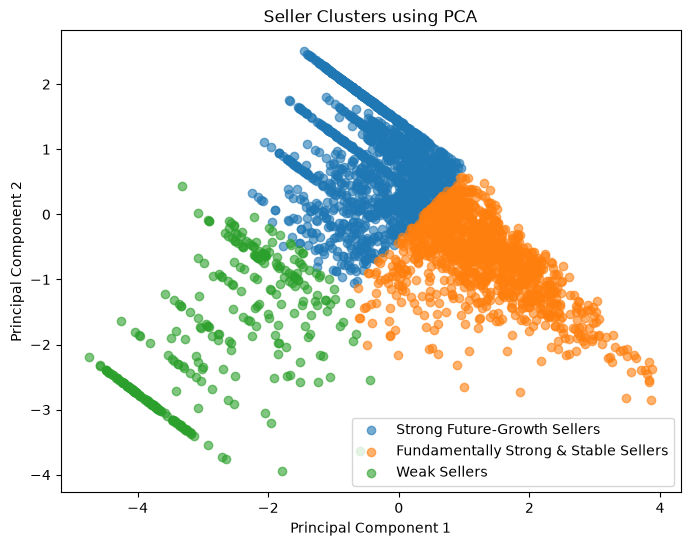

In [40]:
cluster_labels = {
    0: "Strong Future-Growth Sellers",
    1: "Fundamentally Strong & Stable Sellers",
    2: "Weak Sellers"
}
data["seller_segment"] = data["cluster"].map(cluster_labels)

plt.figure(figsize=(8, 6))
for cluster, label in cluster_labels.items():
    mask = data["cluster"] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.6, label=label)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Seller Clusters using PCA")
plt.legend()
plt.show()


### 8.9 Export Segment Lists

In [41]:
strong_future_growth_sellers = data.loc[data["cluster"] == 0, "seller_id"].tolist()
fundamentally_strong_stable_sellers = data.loc[data["cluster"] == 1, "seller_id"].tolist()
weak_sellers = data.loc[data["cluster"] == 2, "seller_id"].tolist()

print(f"Strong future-growth sellers: {len(strong_future_growth_sellers)}")
print(f"Fundamentally strong & stable sellers: {len(fundamentally_strong_stable_sellers)}")
print(f"Weak sellers: {len(weak_sellers)}")


Strong future-growth sellers: 1598
Fundamentally strong & stable sellers: 1165
Weak sellers: 332


## 9. Conclusion & Recommendations

**Delivery delay:**
- ~ 8% of orders arrive later than the estimated delivery date (see 4.1).
- The strongest measured driver of delay is **carrier transit time** (ρ = 0.235), followed by
  **seller-customer distance** (ρ ≈ 0.18) and **seller processing time** (ρ = 0.173). Package
  volume has negligible effect.
- Delay has a weak but real negative relationship with review scores (ρ = -0.178) — delay is
  costing satisfaction, even if it's not the dominant factor.

**Recommendations:**
1. Prioritize carrier/logistics optimization on high-transit-time routes over package-size
   restrictions.
2. Work with sellers who have slow dispatch times (processing time) — the composite KPI and
   cluster analysis above identify who those are.
3. Support the sellers who are struggling, and invest more in the sellers who are doing well but still small — so they can grow.
4. EMI/installment payment options are associated with materially higher order values (~65%) —
   worth testing whether expanding installment availability increases average order value
   causally (this analysis shows correlation, not causation).

In [ ]:
conn.close()